#Project Roadmap: Customer Support RAG Chatbot
##Milestone 1: Data Collection & Preprocessing (Current Focus)
###1.1 Refined Ingestion: Consolidating PDF, DOCX, CSV, XLSX into a single .md while injecting strict Metadata Tags (# SOURCE: filename).

###1.2 Advanced Preprocessing: Cleaning noise (regex) and Semantic Chunking (preserving headers and tables).

###1.3 EDA & Validation: Analyzing topic distribution to ensure no "Unknown" sources remain.

##Milestone 2: Model Development & Evaluation
###2.1 Vector Store Creation: Setting up the database (FAISS or Azure AI Search) and generating Embeddings.

###2.2 RAG Pipeline Config: Connecting the Retriever (Vector DB) to the Generator (LLM).

###2.3 Evaluation: Testing accuracy using ROUGE/BLEU metrics.

##Milestone 3: Advanced Techniques & Azure Deployment
###3.1 Azure Integration: Hosting the model via Azure App Service.

###3.2 API Development: Creating a REST API for your support portal.

##Milestone 4: MLOps & Monitoring
###4.1 Tracking: Using MLflow to track different prompt versions.

###4.2 Performance Monitoring: Tracking latency and user satisfaction.

In [32]:
%pip install pymupdf4llm python-docx pandas openpyxl matplotlib wordcloud langchain-text-splitters faiss-cpu sentence-transformers langchain-community langchain-huggingface
%pip install --upgrade pillow wordcloud

  Using cached faiss_cpu-1.13.2-cp314-cp314-win_amd64.whl.metadata (7.6 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached langchain_community-0.4.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_huggingface-1.2.2-py3-none-any.whl.metadata (4.0 kB)
  Using cached transformers-5.6.1-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.11.0-py3-none-any.whl.metadata (14 kB)
  Using cached torch-2.11.0-cp314-cp314-win_amd64.whl.metadata (29 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached regex-2026.4.4-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.24.2-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.m

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\Lenovo\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\safetensors-0.7.0.dist-info\\METADATA'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
    --------------------------------------- 0.3/18.9 MB ? eta -:--:--
   - -------------------------------------- 0.8/18.9 MB 2.6 MB/s eta 0:00:07
   --- ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Step 1.1: The Ingestion Script
This version of the code ensures that even though everything is in one .md file, the transition between files is crystal clear for the chunker.

2. The Professional Ingestion Script
This script iterates through the companykb folder, validates extensions, and compiles everything into a single knowledge_base.md file with clear metadata headers for the RAG retriever.

In [12]:
import os
import pandas as pd
import pymupdf4llm
from docx import Document
from pathlib import Path
from datetime import datetime

class KBConverter:
    """
    Professional Ingestion Engine for RAG Knowledge Bases.
    Converts PDF, DOCX, CSV, and XLSX into a Structured Markdown Corpus.
    """
    def __init__(self, input_folder, output_file):
        self.input_path = Path(input_folder)
        self.output_file = output_file
        self.supported_extensions = {
            '.pdf': self._handle_pdf,
            '.docx': self._handle_docx,
            '.doc': self._handle_docx, # docx library handles most modern .doc
            '.csv': self._handle_csv,
            '.xlsx': self._handle_xlsx
        }

    def _handle_pdf(self, file_path):
        # High-fidelity PDF to MD conversion preserving tables and layout using pymupdf4llm
        return pymupdf4llm.to_markdown(str(file_path))

    def _handle_docx(self, file_path):
        # Extract text from DOCX while preserving paragraphs
        doc = Document(file_path)
        return "\n".join([para.text for para in doc.paragraphs])

    def _handle_csv(self, file_path):
        # Convert CSV to Markdown table using pandas for better formatting
        df = pd.read_csv(file_path)
        return df.to_markdown(index=False)

    def _handle_xlsx(self, file_path):
        # Reads all sheets and combines them
        excel_data = pd.read_excel(file_path, sheet_name=None)
        md_output = ""
        for sheet_name, df in excel_data.items():
            md_output += f"\n### Sheet: {sheet_name}\n\n"
            md_output += df.to_markdown(index=False) + "\n"
        return md_output

    def process(self):
        if not self.input_path.exists():
            print(f"Error: Folder '{self.input_path}' not found.")
            return
        
        # Initialize the file with a professional metadata header
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        final_content = [f"# KNOWLEDGE BASE EXPORT\nGenerated: {timestamp}\n" + "="*30 + "\n"]
        
        # Sort files to maintain consistent ingestion order
        for file in sorted(self.input_path.iterdir()):
            ext = file.suffix.lower()
            if ext in self.supported_extensions:
                print(f"Processing/Ingesting: {file.name}...")
                try:
                    content = self.supported_extensions[ext](file)
                    # Wrap each file in a header for RAG context
                    # Apply the Structured Markdown Scheme
                    section_header = f"\n\n# SOURCE_FILE: {file.name}\n" + "====================\n"
                    final_content.append(section_header + content)
                except Exception as e:
                    print(f"Failed to process {file.name}: {e}")
            else:
                # Requirement: Skip and message unsupported files
                if file.is_file():
                    print(f"Skipping unsupported format: {file.name} - File type {ext} is not supported.")

        # Write the consolidated MD file
        with open(self.output_file, "w", encoding="utf-8") as f:
            f.write("\n".join(final_content))
        
        print(f"\n Success! All data compiled into: {self.output_file}")

In [13]:
converter = KBConverter(input_folder="companykb", output_file="knowledge_base.md")
converter.process()

Processing/Ingesting: productsandprices.pdf...
Processing/Ingesting: refundpolicy.docx...
Processing/Ingesting: zbranches.xlsx...

 Success! All data compiled into: knowledge_base.md


Milestone 1: Step 1.2 - Advanced Preprocessing
Turn the MArkdown file into Semantic Chunks. So when a user asks a Q; the system retrieves only the relevant answer "slice" of data not the whole doc.

In [14]:
import re
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

class KBPreprocessor:
    def __init__(self, chunk_size=700, chunk_overlap=70):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        
        self.headers_to_split_on = [
            ("#", "source_file"),
            ("##", "section_header"),
            ("###", "sub_section")
        ]

    def clean_text(self, text):
        """
        Gentle cleaning: Preserves Markdown structure (tables) 
        and Multilingual characters (Arabic).
        """
        # 1. Lowercase (helps with English matching, ignores Arabic)
        text = text.lower()
        
        # 2. Remove placeholders like {{...}}
        text = re.sub(r"\{\{.*?\}\}", " ", text)
        
        # 3. Remove specific artifacts (like <br>) without breaking markdown
        text = re.sub(r'\bbr\b', " ", text)
        text = re.sub(r'\bnbsp\b', " ", text)
        
        # 4. Clean up excessive horizontal spaces, but STRICTLY PRESERVE newlines (\n)
        # This keeps the table rows intact!
        text = re.sub(r'[ \t]+', ' ', text).strip()
        return text

    def process(self, file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            raw_text = f.read()

        md_splitter = MarkdownHeaderTextSplitter(
            headers_to_split_on=self.headers_to_split_on,
            strip_headers=False
        )
        md_docs = md_splitter.split_text(raw_text)

        # Metadata cleanup
        for doc in md_docs:
            if "source_file" in doc.metadata:
                clean_name = doc.metadata["source_file"].replace("SOURCE_FILE:", "").strip()
                doc.metadata["source_file"] = clean_name

        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=self.chunk_size,
            chunk_overlap=self.chunk_overlap,
            # We add markdown table pipes "|" as a separator to avoid splitting rows in half
            separators=["\n\n", "\n", "|", ".", " "]

        )
        
        final_chunks = text_splitter.split_documents(md_docs)

        # Clean content
        for chunk in final_chunks:
            chunk.page_content = self.clean_text(chunk.page_content)

        print(f" Preprocessing Complete: Created {len(final_chunks)} cleaned chunks.")
        return final_chunks

# --- NOTEBOOK EXECUTION ---
preprocessor = KBPreprocessor()
chunks = preprocessor.process("knowledge_base.md")

 Preprocessing Complete: Created 21 cleaned chunks.


In [15]:
# 3. Verification test: check few random chunks to verify the source metadata
# Check a few random chunks to verify the source metadata
if len(chunks) > 0:
    print(f"Total Chunks Created: {len(chunks)}")
    
    # We will check chunk [1] or [2] to bypass the "Export Header" at the very top of the file
    test_chunk = chunks[1] if len(chunks) > 1 else chunks[0]
    
    print(f"Metadata Key Check: {test_chunk.metadata.keys()}")
    print(f"Example Source: {test_chunk.metadata.get('source_file')}")
    print(f"Example Content: {test_chunk.page_content[:100]}...")
else:
    print("No chunks created.")

Total Chunks Created: 21
Metadata Key Check: dict_keys(['source_file'])
Example Source: productsandprices.pdf
Example Content: # source_file: productsandprices.pdf
====================...


Milestone 1: Step 3 - Exploratory Data Analysis (EDA)
The objective here is to analyze your final_chunks to ensure the knowledge base is balanced and to identify which topics (e.g., Mattresses vs. Refund Policy) are most prominent."CHINK DISTRIBUTION"

1. The EDA Implementation Code
We will use pandas, matplotlib, and wordcloud to visualize the density of the knowledge base.

 --- RAG KNOWLEDGE BASE EDA REPORT --- 📊

Total Chunks: 21
Average Character Count: 414 chars
Average Word Count: 57 words

 --- CHUNKS PER SOURCE FILE ---
Source_File
productsandprices.pdf    8
refundpolicy.docx        7
zbranches.xlsx           5
KNOWLEDGE BASE EXPORT    1


 --- TOP 10 MOST FREQUENT WORDS ---
- mattress: 12 times
- ميموري: 8 times
- customer: 8 times
- return: 7 times
- بوكيت: 6 times
- cityfoam: 6 times
- within: 6 times
- must: 6 times
- منفصلة،: 5 times
- warranty: 5 times


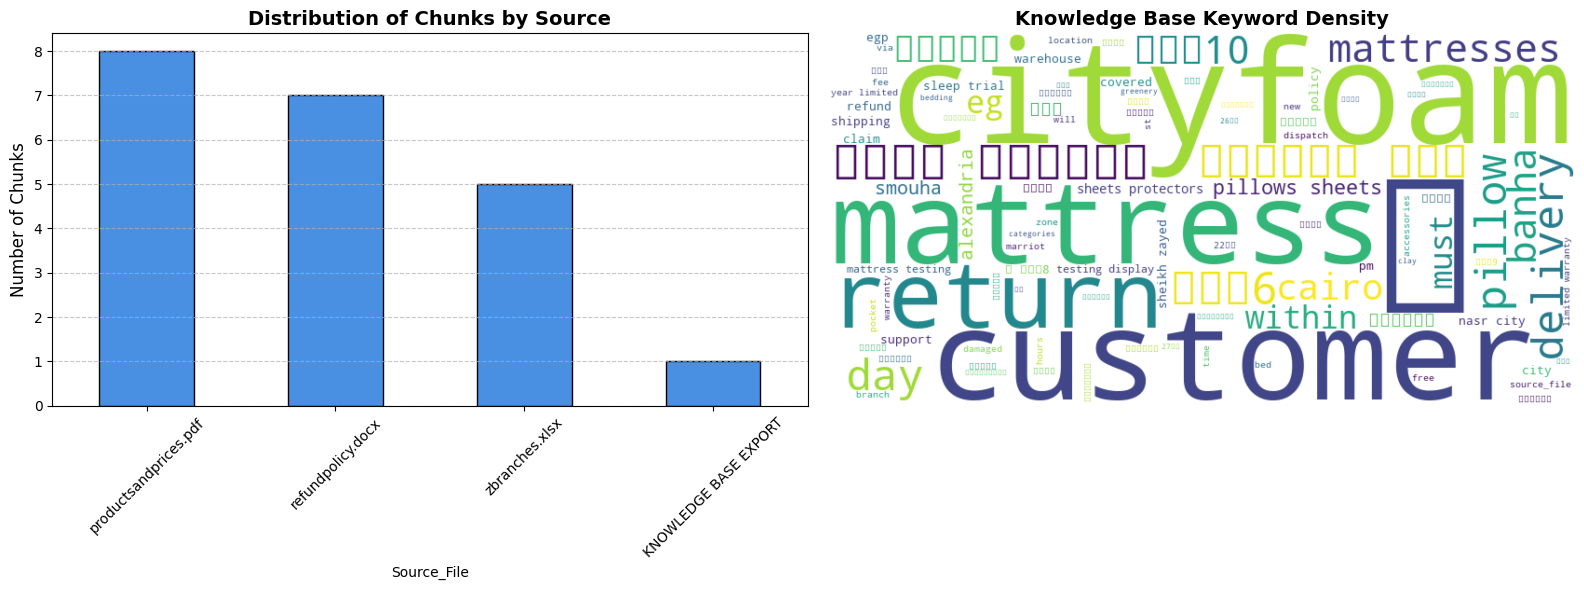

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

def generate_full_eda_report(chunks):
    """Generates a complete visual and statistical report of the RAG chunks."""
    
    data = []
    all_text_words = [] # To store every word for the Counter and WordCloud
    
    # 1. Extract metadata, stats, and words
    for i, chunk in enumerate(chunks):
        source = chunk.metadata.get("source_file", "Unknown")
        content = chunk.page_content
        
        data.append({
            "Chunk_ID": i,
            "Source_File": source,
            "Char_Count": len(content),
            "Word_Count": len(content.split())
        })
        all_text_words.extend(content.split())
        
    df = pd.DataFrame(data)
    
    # 2. Print Statistical Summary
    print(" --- RAG KNOWLEDGE BASE EDA REPORT --- 📊\n")
    print(f"Total Chunks: {len(df)}")
    print(f"Average Character Count: {df['Char_Count'].mean():.0f} chars")
    print(f"Average Word Count: {df['Word_Count'].mean():.0f} words\n")
    
    print(" --- CHUNKS PER SOURCE FILE ---")
    source_counts = df['Source_File'].value_counts()
    print(source_counts.to_string())
    print("\n")

    # 3. Top Keywords Analysis using collections.Counter
    # We filter out very short words (like 'the', 'and', 'is') to get meaningful terms
    meaningful_words = [word for word in all_text_words if len(word) > 3]
    word_freq = Counter(meaningful_words)
    
    print(" --- TOP 10 MOST FREQUENT WORDS ---")
    for word, freq in word_freq.most_common(10):
        print(f"- {word}: {freq} times")
        
    # 4. Generate Visualizations (1 Row, 2 Columns)
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Source Distribution Bar Chart
    source_counts.plot(kind='bar', ax=ax[0], color='#4A90E2', edgecolor='black')
    ax[0].set_title('Distribution of Chunks by Source', fontsize=14, fontweight='bold')
    ax[0].set_ylabel('Number of Chunks', fontsize=12)
    ax[0].tick_params(axis='x', rotation=45)
    ax[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Plot B: Keyword Density Word Cloud
    all_text_string = " ".join(all_text_words)
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        colormap='viridis',
        max_words=100
    ).generate(all_text_string)
    
    ax[1].imshow(wordcloud, interpolation='bilinear')
    ax[1].axis('off')
    ax[1].set_title("Knowledge Base Keyword Density", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return df

# Pass the 'chunks' list we generated into the function
df_eda = generate_full_eda_report(chunks)

Milestone 2: Model Development & Evaluation
Step 2.1: Vector Store Creation & Embeddings
In this step, we will convert the text chunks into numbers (Embeddings) so the AI can perform a "Semantic Search." Instead of just matching exact words, it will understand the meaning of the user's question.

I will use FAISS (Facebook AI Similarity Search) combined with Hugging Face sentence transformers. This is the industry standard for fast, local vector databases.

2. The Vector Store Code
This code will download BGE-M3 for multilingual support and in the same vectore store :) , convert all chunks into vectors, and save the database locally.

In [17]:
import os
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

class VectorStoreManager:
    def __init__(self, db_path="faiss_index"):
        self.db_path = db_path
        
        # SWITCHED TO BGE-M3 for English + Arabic support
        print(" Loading Multilingual BGE-M3 Model...")
        self.embeddings = HuggingFaceEmbeddings(
            model_name="BAAI/bge-m3",
            model_kwargs={'device': 'cpu'} # Change to 'cuda' if you have a GPU
        )
        self.vector_db = None

    def build_and_save(self, chunks):
        print(f"Embedding {len(chunks)} chunks with BGE-M3. Please wait...")
        # FAISS will automatically handle the 1024-dimension vectors
        self.vector_db = FAISS.from_documents(chunks, self.embeddings)
        self.vector_db.save_local(self.db_path)
        print(f"Multilingual Vector Store saved to '{self.db_path}'!")

    def load_db(self):
        if os.path.exists(self.db_path):
            self.vector_db = FAISS.load_local(
                self.db_path, 
                self.embeddings, 
                allow_dangerous_deserialization=True 
            )
            print(" Multilingual Vector Store loaded.")
            return self.vector_db
        return None

    def test_retrieval(self, query, k=3):
        if not self.vector_db: return
        print(f"\n Searching (EN/AR): '{query}'")
        results = self.vector_db.similarity_search(query, k=k)
        for i, doc in enumerate(results):
            print(f"--- Result {i+1} [Source: {doc.metadata.get('source_file')}] ---")
            print(f"{doc.page_content[:200]}...\n")

vs_manager = VectorStoreManager()
vs_manager.build_and_save(chunks)

 Loading Multilingual BGE-M3 Model...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 22624.37it/s]


Embedding 21 chunks with BGE-M3. Please wait...
Multilingual Vector Store saved to 'faiss_index'!


In [18]:
# Test 1: English Query
vs_manager.test_retrieval("What is the price of Ripa?")

# Test 2: Arabic Query (Checking for the same product)
vs_manager.test_retrieval("ما هو سعر كونتور ميموري فوم؟")


 Searching (EN/AR): 'What is the price of Ripa?'
--- Result 1 [Source: productsandprices.pdf] ---
## **3. قسم المخدات (pillows)** 
)نقدم تشكيلة من المخدات الطبية ومخدات السفر بأسعار تنافسية (األسعار بالجنيه المصري: 
|**اسم المخدة**|**الوصف و لستخدام**|**السعر قبل**< >**الخصم**|**السعر الحالي**|**م...

--- Result 2 [Source: productsandprices.pdf] ---
|**ميموري فوم مموجة (wavy)**|دعم الرقبة|1,487ج.م|1,350ج.م|خصم8< >%|
|**مموجة للنوم على الجانب**|مخصصة لمن ينامون على< >الجانب|854ج.م|775ج.م|خصم9< >%|
|**لتكس طبيعي مساج كيرف**|مساج ودعم طبيعي|2,415ج.م...

--- Result 3 [Source: productsandprices.pdf] ---
## **2. قسم المراتب (mattresses)** 
لحتياجات، ويسري عليها حالياً عروض خصم خاصةتتوفر مراتب سيتي فوم بارتفاعات ومواصفات مختلفة لتناسب كافة : 
|**اسم المرتبة**|**المواصفات**|**لرتفاع**|**نسبة الخصم**|
|-...


 Searching (EN/AR): 'ما هو سعر كونتور ميموري فوم؟'
--- Result 1 [Source: productsandprices.pdf] ---
|**ميموري فوم مموجة (wavy)**|دعم الرقبة|1,487ج.م|1,350ج.م|خصم8< >%|
|**مموجة للنوم على 